### Bhanu's testbed functions

In [1]:
import numpy as np

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

def fit_and_score_features(X, y):
    """Univariate CoxPH feature scoring for SelectKBest (must return float p-values)."""
    scores = []
    for i in range(X.shape[1]):
        try:
            model = CoxPHSurvivalAnalysis().fit(X[:, [i]], y)
            risk_scores = model.predict(X[:, [i]])
            score = concordance_index_censored(y["event"], y["time"], risk_scores)[0]
        except Exception:
            score = 0.0
        scores.append(score)

    scores = np.asarray(scores, dtype=float)
    pvals = np.ones_like(scores, dtype=float)
    return scores, pvals

In [2]:
import os
import joblib
import numpy as np

# ---- Load survival bundle (includes models + preproc + static + true) ----
SURV_BUNDLE_PATH = "saved_survival_models/best_models_bundle.joblib"
surv_bundle = joblib.load(SURV_BUNDLE_PATH)

best_model_per_user = surv_bundle["best_model_per_user"]
preproc_per_user = surv_bundle["preproc_per_user"]
static_feature_lookup = surv_bundle["static_feature_lookup"]
true_brushing = surv_bundle.get("true_brushing", None)  # should exist if you saved it
user_metadata = surv_bundle["user_metadata"]

print("Loaded survival models for:", len(best_model_per_user), "users")
print("Loaded static_feature_lookup for:", len(static_feature_lookup), "users")
if true_brushing is not None:
    print("Loaded true_brushing for:", len(true_brushing), "users")

# ---- Brushing quality models dir ----
BQ_DIR = "saved_brushing_quality_models"

def load_bq_payload(user_id):
    path = os.path.join(BQ_DIR, f"{user_id}_bq.joblib")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing brushing-quality model for {user_id}: {path}")
    return joblib.load(path)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SelectKBest from version 1.6.1 when using version 1.8.0. This might lead to breakin

Loaded survival models for: 69 users
Loaded static_feature_lookup for: 69 users
Loaded true_brushing for: 69 users


In [3]:
import numpy as np

def log_clip(y):
    """pickle-friendly log transform used in TransformedTargetRegressor"""
    y = np.asarray(y)
    return np.log(np.clip(y, 1e-8, None))

def exp_transform(y):
    """inverse of log_clip"""
    return np.exp(y)

import numpy as np
from scipy.stats import invgamma

class BayesLinRegUnknownVariance:
    def __init__(self, mu_0, sigma_0, alpha, beta):
        self.mu_0 = mu_0                   # Prior mean vector (d,)
        self.Sigma_0 = np.diag(sigma_0)    # Prior covariance matrix (d,d)
        self.alpha = alpha                 # Prior shape parameter for variance
        self.beta = beta                   # Prior scale parameter for variance
        self.X_hist = []                   # Historical X observations
        self.y_hist = []                   # Historical y observations

    def update(self, X, y):
        self.X_hist.append(X)
        self.y_hist.append(np.atleast_1d(y))

    def has_data(self):
        return len(self.X_hist) > 0

    def prior(self):
        return self.mu_0, self.Sigma_0, self.alpha, self.beta

    def posterior(self):
        """
        Compute posterior parameters given observed data.
        Returns updated (mu_n, Sigma_n, alpha_n, beta_n).
        """
        X = np.vstack(self.X_hist)
        y = np.concatenate(self.y_hist)
        Sigma_0_inv = np.linalg.inv(self.Sigma_0)
        
        Sigma_n_inv = Sigma_0_inv + X.T @ X
        Sigma_n = np.linalg.inv(Sigma_n_inv)
        mu_n = Sigma_n @ (Sigma_0_inv @ self.mu_0 + X.T @ y)

        alpha_n = self.alpha + len(y) / 2
        residuals = y - X @ mu_n
        beta_n = self.beta + 0.5 * (residuals.T @ residuals +
                                    (mu_n - self.mu_0).T @ Sigma_0_inv @ (mu_n - self.mu_0))
        return mu_n, Sigma_n, alpha_n, beta_n

    def predict_given(self, mu_n, Sigma_n, alpha_n, beta_n, x_query):
        """
        Predict distribution at new x_query given posterior parameters.
        x_query shape: (1, d) or (d,)
        """

        # Ensure everything is 1D where appropriate
        x = np.asarray(x_query).reshape(-1)      # shape (d,)
        mu = np.asarray(mu_n).reshape(-1)        # shape (d,)
        Sigma = np.asarray(Sigma_n)              # shape (d,d)

        # Predictive mean: x^T mu
        pred_mean = float(x.dot(mu))

        # Predictive variance: (beta_n / (alpha_n - 1)) * (1 + x^T Sigma x)
        quad_form = float(x.dot(Sigma).dot(x))
        pred_var = float((beta_n / (alpha_n - 1)) * (1 + quad_form))

        return pred_mean, pred_var


In [4]:
def compute_exponential_avg(values):
    if values is None or len(values) == 0:
        return 0
    gamma = (len(values) - 1) / len(values)
    discounted_gamma_array = gamma ** (np.arange(len(values)))  # First values get highest weight
    constant = (1 - gamma) / (1 - gamma ** len(values))
    sum_term = discounted_gamma_array * values
    return round(constant * np.sum(sum_term), 2)


def get_simulated_brush_quality(model_pipeline,scaler,best_features,decision_time,start_date,simulated_brush_time,simulated_actions,simulated_brush_quality,action,ut):
    select_k = model_pipeline.named_steps["select"] 
    model = model_pipeline.named_steps["model"]

    #print(best_features)
    feature=[]

    if(decision_time.hour==16):
        feature.append(1)
    else:
        feature.append(0)

    #today=start_date+timedelta(days=(decision_idx-1)//2)
    #feature.append(today.weekday())
    feature.append(decision_time.weekday())

    FOUR_AM  = time(4, 0)
    FOUR_PM  = time(16, 0)

    missed_count=0
    same_window_brush_quality=[]
    for i in range(1,8):
        if get_or_none(simulated_brush_quality,-2*i) is not None:
            #print(i,len(simulated_brush_time),get_or_nosne(simulated_brush_time,-2*i))
            prior_day_brush_quality=simulated_brush_quality[-2*i]
            if(prior_day_brush_quality is None):
                missed_count+=1
            else:
                same_window_brush_quality.append(prior_day_brush_quality)
   # print(same_window_brush_quality)

    if(len(same_window_brush_quality)==0):
        most_recent_brush_quality=180
        missed_count=7
        same_window_brush_quality=[0]
    else:
        most_recent_brush_quality=same_window_brush_quality[-1]

    same_window_brush_quality_feature=[ round(np.min(same_window_brush_quality),2) if len(same_window_brush_quality) > 0 else 0,
    round(np.max(same_window_brush_quality),2) if len(same_window_brush_quality) > 0 else 0,
    round(compute_exponential_avg(same_window_brush_quality),2) if len(same_window_brush_quality) > 0 else 0,
    safe_std_mean_ratio(same_window_brush_quality),
    missed_count ]

    feature+=same_window_brush_quality_feature


    # if(len(same_window_brush_quality)==0):
    #     most_recent_brush_quality=180
    # else:
    #     most_recent_brush_quality=same_window_brush_quality[-1]
    
    missed_count=0
    opposite_window_brush_quality=[]
    for i in range(1,8):
        if get_or_none(simulated_brush_quality,-2*i+1) is not None:
            #print(i,len(simulated_brush_time),get_or_none(simulated_brush_time,-2*i))
            prior_day_brush_quality=simulated_brush_quality[-2*i+1]
            if(prior_day_brush_quality is None):
                missed_count+=1
            else:
                opposite_window_brush_quality.append(prior_day_brush_quality)

    if(len(opposite_window_brush_quality)==0):
        opposite_window_brush_quality=[0]
        missed_count=7

    opposite_window_brush_quality_feature=[ round(np.min(opposite_window_brush_quality),2) if len(opposite_window_brush_quality) > 0 else 0,
    round(np.max(opposite_window_brush_quality),2) if len(opposite_window_brush_quality) > 0 else 0,
    round(compute_exponential_avg(opposite_window_brush_quality),2) if len(opposite_window_brush_quality) > 0 else 0,
    safe_std_mean_ratio(opposite_window_brush_quality),
    missed_count ]
    feature+=opposite_window_brush_quality_feature

    feature+=[most_recent_brush_quality]

    
    past_actions=[]
    for i in range(1,8):
        if get_or_none(simulated_actions,-2*i) is not None:
            past_actions.append(simulated_actions[-2*i])
    
    past_actions=np.array(past_actions)
    past_actions_12_hours_back=0
    if get_or_none(simulated_actions,-1) is not None:
        past_actions_12_hours_back=simulated_actions[-1]
    action_features=[compute_exponential_avg(past_actions),past_actions_12_hours_back,action]
    feature+=action_features

    feature+=[ut]


    feature = np.array(feature).reshape(1, -1)
    feature = scaler.transform(feature)
    feature=feature[:,best_features]

    Y_pred=model.predict(feature)[0]

    #cap Y_pred between 0 and 180
    Y_pred=max(0,min(180,Y_pred))


    #print(len(feature),Y_pred)
    


    return round(Y_pred,2)

In [5]:
def evaluate_simulation(Y_true, Y_simulated):
    """
    Compare simulation against true brushing data.

    Returns:
        Dictionary with evaluation metrics.
    """
    # Extract from structured arrays
    true_event = Y_true["event"]
    true_time = Y_true["time"]
    sim_event = Y_simulated["event"]
    sim_time = Y_simulated["time"]

    # Proportion right-censored
    prop_censored_true = 1.0 - np.mean(true_event)
    prop_censored_sim = 1.0 - np.mean(sim_event)

    # Mean brushing time
    mean_time_true = np.mean(true_time[true_event]) if np.any(true_event) else np.nan
    mean_time_sim = np.mean(sim_time[sim_event]) if np.any(sim_event) else np.nan

    # 90th percentile brushing time
    p90_time_true = np.percentile(true_time[true_event], 90) if np.any(true_event) else np.nan
    p90_time_sim = np.percentile(sim_time[sim_event], 90) if np.any(sim_event) else np.nan

    #75th percentile brushing time
    p75_time_true = np.percentile(true_time[true_event], 75) if np.any(true_event) else np.nan
    p75_time_sim = np.percentile(sim_time[sim_event], 75) if np.any(sim_event) else np.nan

    std_time_true = np.std(true_time[true_event]) if np.any(true_event) else np.nan
    std_time_sim = np.std(sim_time[sim_event]) if np.any(sim_event) else np.nan

    median_time_true = np.median(true_time[true_event]) if np.any(true_event) else np.nan
    median_time_sim = np.median(sim_time[sim_event]) if np.any(sim_event) else np.nan

    return {
        "prop_censored_true": round(prop_censored_true, 3),
        "prop_censored_sim": round(prop_censored_sim, 3),
        "mean_time_true": round(mean_time_true, 2),
        "mean_time_sim": round(mean_time_sim, 2),
        "p90_time_true": round(p90_time_true, 2),
        "p90_time_sim": round(p90_time_sim, 2),
        "p75_time_true": round(p75_time_true, 2),
        "p75_time_sim": round(p75_time_sim, 2),
        "std_time_true": round(std_time_true, 2),
        "std_time_sim": round(std_time_sim, 2),
        "median_time_true": round(median_time_true, 2),
        "median_time_sim": round(median_time_sim, 2),
    }


In [6]:

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.linear_model import GammaRegressor
from sklearn.ensemble import GradientBoostingRegressor

class PositiveResidualStack(BaseEstimator, RegressorMixin):
    def __init__(self, base=GammaRegressor(max_iter=5000),
                 resid=GradientBoostingRegressor(random_state=42), eps=1e-8):
        self.base, self.resid, self.eps = base, resid, eps
    def fit(self, X, y):
        y = np.array(y, float)
        self.base_ = clone(self.base).fit(X, y)
        mu0 = np.clip(self.base_.predict(X), self.eps, None)
        r = np.log(y) - np.log(mu0)
        self.resid_ = clone(self.resid).fit(X, r)
        return self
    def predict(self, X):
        mu0 = np.clip(self.base_.predict(X), self.eps, None)
        rhat = self.resid_.predict(X)
        return mu0 * np.exp(rhat)  # > 0

### Reinforcement learning

#### Learning algorithm

In [7]:
def simple_normal_learner(rewards, actions, n_arms):
    """
    Estimate mean (m) and variance (v) for each arm for a single participant,
    given observed rewards and actions so far.
    Args:
        rewards: list or array of observed rewards (length T)
        actions: list or array of chosen arms (length T)
        n_arms: number of arms
    Returns:
        m: array of estimated means for each arm (shape: n_arms,)
        v: array of estimated variances for each arm (shape: n_arms,)
    """
    m = np.zeros(n_arms)
    v = np.ones(n_arms)
    for a in range(n_arms):
        arm_rewards = [r for r, act in zip(rewards, actions) if act == a]
        if len(arm_rewards) > 0:
            m[a] = np.mean(arm_rewards)
            v[a] = np.var(arm_rewards) if len(arm_rewards) > 1 else 1.0  # Use 1.0 if only one sample
        else:
            m[a] = 0.0
            v[a] = 1.0
    return m, v

#### Empirical Bayes decision-making

In [8]:
from scipy.stats import norm

def simple_normal_learner(rewards, actions, n_arms):
    """
    Per-user arm-wise sample mean and variance from observed rewards so far.
    """
    m = np.zeros(n_arms, dtype=float)
    v = np.ones(n_arms, dtype=float)

    for a in range(n_arms):
        arm_rewards = [r for r, act in zip(rewards, actions) if act == a]
        if len(arm_rewards) > 0:
            m[a] = float(np.mean(arm_rewards))
            v[a] = float(np.var(arm_rewards)) if len(arm_rewards) > 1 else 1.0
        else:
            m[a] = 0.0
            v[a] = 1.0

    return m, v


def fit_mu_tau2_across_users(m_list, v_list):
    """
    Empirical Bayes moment estimator across users for ONE arm.

    Args:
        m_list: list of per-user means for this arm
        v_list: list of per-user variances for this arm

    Returns:
        mu_hat, tau2_hat
    """
    m_arr = np.asarray(m_list, dtype=float)
    v_arr = np.asarray(v_list, dtype=float)

    if len(m_arr) == 0:
        return 0.0, 1.0

    mu_hat = float(np.mean(m_arr))

    # moment-matching:
    # Var(m_i) ≈ tau^2 + average estimation noise
    # so tau^2 ≈ sample variance of m_i minus average v_i
    tau2_hat = float(np.var(m_arr) - np.mean(v_arr))
    tau2_hat = max(tau2_hat, 1e-6)

    return mu_hat, tau2_hat


def estimate_global_eb_hyperparams(all_histories, n_arms):
    """
    Estimate EB hyperparameters arm-by-arm using all users' histories seen so far.

    all_histories: dict[user_id] = {"rewards": [...], "actions": [...]}
    """
    mu_hat = np.zeros(n_arms, dtype=float)
    tau2_hat = np.ones(n_arms, dtype=float)

    # get each user's current learner summary
    user_summaries = {}
    for uid, hist in all_histories.items():
        rewards = hist["rewards"]
        actions = hist["actions"]
        m_u, v_u = simple_normal_learner(rewards, actions, n_arms)
        user_summaries[uid] = (m_u, v_u)

    for a in range(n_arms):
        m_list = []
        v_list = []

        for uid, (m_u, v_u) in user_summaries.items():
            # only include users who have actually pulled arm a at least once
            if any(act == a for act in all_histories[uid]["actions"]):
                m_list.append(m_u[a])
                v_list.append(v_u[a])

        mu_hat[a], tau2_hat[a] = fit_mu_tau2_across_users(m_list, v_list)

    return mu_hat, tau2_hat


def empirical_bayes_action_single(m, v, mu_hat, tau2_hat, n_arms=2, rng=None):
    """
    EB action selection for one user, given:
      - current user arm estimates m, v
      - population hyperparameters mu_hat, tau2_hat
    """
    if rng is None:
        rng = np.random.default_rng()

    m = np.asarray(m, dtype=float)
    v = np.maximum(np.asarray(v, dtype=float), 1e-6)
    mu_hat = np.asarray(mu_hat, dtype=float)
    tau2_hat = np.maximum(np.asarray(tau2_hat, dtype=float), 1e-6)

    # posterior mean/variance under normal-normal shrinkage
    lam = tau2_hat / (tau2_hat + v)
    m_eb = lam * m + (1.0 - lam) * mu_hat
    v_eb = 1.0 / (1.0 / v + 1.0 / tau2_hat)

    # Thompson-style sampling from EB posterior
    sampled_values = rng.normal(loc=m_eb, scale=np.sqrt(v_eb))
    action = int(np.argmax(sampled_values))

    return action, m_eb, v_eb

#### Thompson sampling

In [9]:
def thompson_action_single(m, v, n_arms=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    m = np.asarray(m, dtype=float)
    v = np.maximum(np.asarray(v, dtype=float), 1e-6)

    sampled_values = rng.normal(loc=m, scale=np.sqrt(v))
    return int(np.argmax(sampled_values))

In [10]:
def pooled_normal_learner(all_bandit_histories, n_arms):
    m = np.zeros(n_arms)
    v = np.ones(n_arms)

    for a in range(n_arms):
        arm_rewards = []

        for user_id, hist in all_bandit_histories.items():
            rewards = hist["rewards"]
            actions = hist["actions"]
            arm_rewards.extend([r for r, act in zip(rewards, actions) if act == a])

        arm_rewards = np.array(arm_rewards, dtype=float)
        n = len(arm_rewards)

        if n == 0:
            m[a] = 0.0
            v[a] = 1.0
        elif n == 1:
            m[a] = arm_rewards[0]
            v[a] = 1.0
        else:
            m[a] = np.mean(arm_rewards)
            sample_var = np.var(arm_rewards, ddof=1)
            v[a] = max(sample_var / n, 1e-6)

    return m, v

### Run simulation

In [11]:
# # ============================
# # LOAD SAVED MODELS + STATIC FEATURES (NEW)
# # ============================

# import os
# import joblib
# import numpy as np
# import pandas as pd
# from datetime import datetime, timedelta, time
# from collections import defaultdict
# from sksurv.util import Surv
# import pickle
# import matplotlib.pyplot as plt

# import warnings
# from sklearn.exceptions import InconsistentVersionWarning
# warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

# # ---- paths ----
# SURV_BUNDLE_PATH = "saved_survival_models/best_models_bundle.joblib"
# BQ_DIR = "saved_brushing_quality_models"

# # ---- load survival bundle (models + preproc + static_feature_lookup + true_brushing) ----
# surv_bundle = joblib.load(SURV_BUNDLE_PATH)

# best_model_per_user = surv_bundle["best_model_per_user"]
# preproc_per_user = surv_bundle["preproc_per_user"]
# static_feature_lookup = surv_bundle["static_feature_lookup"]
# true_brushing = surv_bundle.get("true_brushing", None)  # should exist if you saved it

# print("✅ Loaded survival models for:", len(best_model_per_user), "users")
# print("✅ Loaded static_feature_lookup for:", len(static_feature_lookup), "users")
# if true_brushing is not None:
#     print("✅ Loaded true_brushing for:", len(true_brushing), "users")
# else:
#     print("⚠️ true_brushing not found in bundle. Some evaluation code may fail.")

# def load_bq_payload(user_id, bq_dir=BQ_DIR):
#     path = os.path.join(bq_dir, f"{user_id}_bq.joblib")
#     if not os.path.exists(path):
#         raise FileNotFoundError(f"Missing brushing-quality model for {user_id}: {path}")
#     return joblib.load(path)


# # ============================
# # Feedback features (unchanged)
# # ============================

# from sklearn.feature_selection import SelectKBest, f_regression

# def safe_std_mean_ratio(hours):
#     if len(hours) == 0 or np.mean(hours) == 0:
#         return 0
#     return round((np.std(hours) / np.mean(hours)), 2)

# def compute_feedback_features(simulated_brushing_times, decision_time, start_date, static_features):
#     morning_array, evening_array = [], []
#     morning_hours, evening_hours = [], []
#     morning_missed_count, evening_missed_count = 0, 0
#     time_delta = static_features[-4]

#     for i in range(1, 8):
#         prior_day_time = decision_time + timedelta(days=-i)
#         if prior_day_time.date() < start_date:
#             continue

#         morning_start = prior_day_time.replace(hour=4, minute=0, second=0, microsecond=0)
#         morning_end = morning_start + timedelta(hours=12)
#         evening_start = prior_day_time.replace(hour=16, minute=0, second=0, microsecond=0)
#         evening_end = evening_start + timedelta(hours=12)

#         # Morning brushing
#         morning_bt = [bt for bt in simulated_brushing_times if morning_start <= bt < morning_end]
#         if morning_bt:
#             bt = morning_bt[0]
#             delta = (bt - morning_start).total_seconds() / 3600
#             morning_array.append(bt)
#             morning_hours.append(round(delta, 2))
#         else:
#             morning_missed_count += 1

#         # Evening brushing
#         evening_bt = [bt for bt in simulated_brushing_times if evening_start <= bt < evening_end]
#         if evening_bt:
#             bt = evening_bt[0]
#             delta = (bt - evening_start).total_seconds() / 3600
#             evening_array.append(bt)
#             evening_hours.append(round(delta, 2))
#         else:
#             evening_missed_count += 1

#     if len(morning_array) == 0:
#         morning_hours = [time_delta]
#         morning_missed_count = 6
#     if len(evening_array) == 0:
#         evening_hours = [time_delta]
#         evening_missed_count = 6

#     morning_hours = np.array(morning_hours)
#     evening_hours = np.array(evening_hours)

#     morning_features = [
#         np.min(morning_hours) if len(morning_hours) > 0 else 0,
#         np.max(morning_hours) if len(morning_hours) > 0 else 0,
#         np.median(morning_hours) if len(morning_hours) > 0 else 0,
#         compute_exponential_avg(morning_hours),
#         safe_std_mean_ratio(morning_hours),
#         morning_missed_count,
#     ]

#     evening_features = [
#         np.min(evening_hours) if len(evening_hours) > 0 else 0,
#         np.max(evening_hours) if len(evening_hours) > 0 else 0,
#         np.median(evening_hours) if len(evening_hours) > 0 else 0,
#         compute_exponential_avg(evening_hours),
#         safe_std_mean_ratio(evening_hours),
#         evening_missed_count,
#     ]

#     if decision_time.hour == 4:
#         brushing_stat_features = morning_features + evening_features
#     else:
#         brushing_stat_features = evening_features + morning_features

#     past_windowed = [btime for btime in simulated_brushing_times if btime < decision_time]

#     morning_brushes, evening_brushes = [], []
#     for dt_key in past_windowed:
#         if 4 <= dt_key.hour < 16:
#             morning_brushes.append(dt_key)
#         else:
#             evening_brushes.append(dt_key)

#     use_list = evening_brushes if decision_time.hour == 16 else morning_brushes

#     if len(use_list) > 0:
#         alpha = use_list[-1]
#         last_brushing_days = (decision_time - alpha).days
#         if last_brushing_days > 7:
#             last_brushing_days = 7

#         minutes_in_day = alpha.hour * 60 + alpha.minute
#         if decision_time.hour == 16 and minutes_in_day <= 240:
#             minutes_in_day += 1440

#         reference_minutes_in_day = decision_time.hour * 60 + decision_time.minute
#         most_recent_brushinghours = round((minutes_in_day - reference_minutes_in_day) / 60, 2)
#     else:
#         last_brushing_days = 1
#         most_recent_brushinghours = time_delta

#     most_recent_array = [last_brushing_days, most_recent_brushinghours]
#     return brushing_stat_features + most_recent_array


# # ============================
# # Sampling from survival func
# # ============================

# def sample_from_survival(sf, t_max=12.0, rng=None):
#     rng = np.random.default_rng() if rng is None else rng

#     t_grid = np.asarray(sf.x, dtype=float)
#     S_grid = np.asarray(sf.y, dtype=float)

#     mask = t_grid <= t_max
#     t_grid = t_grid[mask]
#     S_grid = S_grid[mask]

#     if t_grid.size == 0:
#         return False, float(t_max)

#     if t_grid[0] > 0.0:
#         t_grid = np.insert(t_grid, 0, 0.0)
#         S_grid = np.insert(S_grid, 0, 1.0)

#     if t_grid[-1] < t_max:
#         t_grid = np.append(t_grid, t_max)
#         S_grid = np.append(S_grid, S_grid[-1])

#     u = rng.uniform()

#     idx = np.argmax(S_grid <= u)
#     if S_grid[idx] > u:
#         return False, float(t_max)

#     i0 = max(idx - 1, 0)
#     t0, S0 = t_grid[i0], S_grid[i0]
#     t1, S1 = t_grid[idx], S_grid[idx]

#     if S0 == S1:
#         t_star = t1
#     else:
#         w = (S0 - u) / (S0 - S1)
#         w = float(np.clip(w, 0.0, 1.0))
#         t_star = t0 + w * (t1 - t0)

#     t_star = float(min(max(t_star, 0.0), t_max))
#     return True, t_star


# # ============================
# # Apply saved survival preprocessing
# # ============================

# def apply_user_preproc(X_row, preproc):
#     Xp = preproc["scaler"].transform(X_row)
#     dropped_const = preproc.get("dropped_const", [])
#     if dropped_const is not None and len(dropped_const) > 0:
#         Xp = np.delete(Xp, dropped_const, axis=1)
#     Xp = Xp[:, preproc["kept_idx"]]
#     return Xp


# def get_or_none(seq, idx, default=None):
#     return seq[idx] if -len(seq) <= idx < len(seq) else default

# def get_action_features(simulated_actions, action):
#     past_actions = []
#     for i in range(1, 8):
#         if get_or_none(simulated_actions, -2 * i) is not None:
#             past_actions.append(simulated_actions[-2 * i])

#     past_actions = np.array(past_actions)
#     past_actions_12_hours_back = 0
#     if get_or_none(simulated_actions, -1) is not None:
#         past_actions_12_hours_back = simulated_actions[-1]
#     action_features = [compute_exponential_avg(past_actions), past_actions_12_hours_back, action]
#     return action_features


# # ============================
# # Simulation
# # ============================

# def thompson_action_single(m, v, n_arms=2, rng=None):
#     if rng is None:
#         rng = np.random.default_rng()

#     m = np.asarray(m, dtype=float)
#     v = np.maximum(np.asarray(v, dtype=float), 1e-6)

#     sampled_values = rng.normal(loc=m, scale=np.sqrt(v))
#     return int(np.argmax(sampled_values))


# n_runs = 5
# algorithms = ["eb", "ts"]

# # preload brushing-quality payloads once
# bq_payload_cache = {
#     user_id: load_bq_payload(user_id)
#     for user_id in best_model_per_user.keys()
# }

# # store cumulative reward traces across runs for each algorithm
# cumulative_reward_runs = {alg: [] for alg in algorithms}

# # keep simulation outputs separate by algorithm
# simulation_columns_by_alg = {
#     alg: defaultdict(lambda: {
#         "decision_time": None,
#         "true_result": None,
#         "runs": []
#     })
#     for alg in algorithms
# }

# with open("user_app_opening.pkl", "rb") as f:
#     user_app_opening_prob = pickle.load(f)

# avg_average_brush_sim = {alg: [] for alg in algorithms}
# std_average_brush_sim = {alg: [] for alg in algorithms}
# avg_prop_right_censored = {alg: [] for alg in algorithms}
# std_prop_right_censored = {alg: [] for alg in algorithms}
# avg_p90_brush_sim = {alg: [] for alg in algorithms}
# std_p90_brush_sim = {alg: [] for alg in algorithms}
# avg_std_brush_sim = {alg: [] for alg in algorithms}
# std_std_brush_sim = {alg: [] for alg in algorithms}
# avg_median_brush_sim = {alg: [] for alg in algorithms}
# std_median_brush_sim = {alg: [] for alg in algorithms}

# mu_0 = [-0.12, 0, -0.60, 0, 1.31, -0.50, 0.40, 0.38, 0.33, 5.68]
# sigma_0 = [(1.30)**2, (0.16)**2, (1.06)**2, (0.57)**2, (1.51)**2, (1.21)**2, (0.50)**2, (0.37)**2, (1.93)**2, (1.91)**2]
# alpha_0, beta_0 = 5.01, 21.73

# # C controls how strictly to align intervention time with brushing time.
# C = 5
# alpha = 1
# variant = "Baseline"

# for alg_name in algorithms:
#     print(f"\n===== Running algorithm: {alg_name.upper()} =====")

#     for run in range(n_runs):
#         print(f"Simulation run {run}")
#         rng = np.random.default_rng(run)
#         n_arms = 2

#         all_bandit_histories = {
#             uid: {"rewards": [], "actions": []}
#             for uid in best_model_per_user.keys()
#         }

#         reward_trace = []

#         r_a, r_b = [], []
#         s_a, s_b = [], []
#         t_a, t_b = [], []
#         u_a, u_b = [], []
#         v_a, v_b = [], []

#         coverage_model = []
#         coverage_user = []

#         cumulative_model_outcome = []
#         cumulative_user_outcome = []

#         for user_id in best_model_per_user.keys():
#             start_date = datetime.strptime(
#                 user_metadata[user_id]["user_start_day"], "%Y-%m-%d"
#             ).date()

#             static_df = static_feature_lookup[user_id]
#             decision_times = sorted(static_df.keys())

#             pipeline = best_model_per_user[user_id]
#             preproc = preproc_per_user[user_id]

#             if true_brushing is None:
#                 raise ValueError("true_brushing not loaded from bundle; cannot compute evaluation.")
#             Y_true = true_brushing[user_id]

#             # ---- load brushing quality model from cache ----
#             bq_payload = bq_payload_cache[user_id]
#             user_brushingquality_model = bq_payload["model"]
#             user_brushingquality_features = bq_payload.get("features", None)

#             if "preproc" in bq_payload:
#                 user_brushingquality_scaler = bq_payload["preproc"]["scaler"]
#                 user_brushingquality_dropped_const = bq_payload["preproc"].get("dropped_const", [])
#             else:
#                 user_brushingquality_scaler = bq_payload["scaler"]
#                 user_brushingquality_dropped_const = []

#             if simulation_columns_by_alg[alg_name][user_id]["decision_time"] is None:
#                 simulation_columns_by_alg[alg_name][user_id]["decision_time"] = decision_times
#                 simulation_columns_by_alg[alg_name][user_id]["true_result"] = [
#                     (event, round(tt, 2)) for event, tt in zip(Y_true["event"], Y_true["time"])
#                 ]

#             Y_simulated = []
#             simulated_brushing_times = []
#             simulated_actions = []
#             simulated_brush_time = []
#             simulated_brush_quality = []
#             simulated_app_opening = []
#             participant_model_outcome = []
#             participant_user_outcome = []

#             rewards = all_bandit_histories[user_id]["rewards"]
#             actions = all_bandit_histories[user_id]["actions"]

#             intervention_time_model = BayesLinRegUnknownVariance(
#                 np.array(mu_0), np.array(sigma_0), alpha_0, beta_0
#             )

#             col_means = np.array([0.45, 2.94, 3.36, 7.24, 5.24, 0.30, 1.61, 5.87, 4.41, 0])
#             col_stds  = np.array([0.50, 1.98, 2.40, 2.85, 2.30, 0.24, 1.99, 2.73, 1.59, 1])

#             model_success, model_fail = 0, 0
#             user_success, user_fail = 0, 0

#             for decision_time in decision_times:
#                 static_features_temp = static_df[decision_time]

#                 feedback_features_temp = compute_feedback_features(
#                     simulated_brushing_times, decision_time, start_date, static_features_temp
#                 )

#                 # --- action selection ---
#                 if len(actions) == 0:
#                     action = int(rng.integers(n_arms))
#                 else:
#                     m, v = simple_normal_learner(rewards, actions, n_arms)

#                     if alg_name == "eb":
#                         mu_hat_global, tau2_hat_global = estimate_global_eb_hyperparams(
#                             all_bandit_histories, n_arms
#                         )
#                         action, m_eb, v_eb = empirical_bayes_action_single(
#                             m=m,
#                             v=v,
#                             mu_hat=mu_hat_global,
#                             tau2_hat=tau2_hat_global,
#                             n_arms=n_arms,
#                             rng=rng
#                         )
#                     elif alg_name == "ts":
#                         action = thompson_action_single(
#                             m=m,
#                             v=v,
#                             n_arms=n_arms,
#                             rng=rng
#                         )
#                     else:
#                         raise ValueError(f"Unknown algorithm: {alg_name}")

#                 action_features = get_action_features(simulated_actions, action)

#                 # IMPORTANT: must match training feature construction
#                 X_now = static_features_temp[:3] + feedback_features_temp + [static_features_temp[-4]] + action_features

#                 if intervention_time_model.has_data():
#                     mu_n, Sigma_n, alpha_n, beta_n = intervention_time_model.posterior()
#                 else:
#                     mu_n, Sigma_n, alpha_n, beta_n = mu_0, np.diag(sigma_0), alpha_0, beta_0

#                 X_intervention_time = [
#                     X_now[0], X_now[2],
#                     feedback_features_temp[0], feedback_features_temp[1],
#                     feedback_features_temp[3], feedback_features_temp[4], feedback_features_temp[5],
#                     feedback_features_temp[-1],
#                     X_now[-4],
#                     1
#                 ]
#                 X_intervention_time = np.array(X_intervention_time).reshape(1, -1)
#                 X_intervention_time = (X_intervention_time - col_means) / col_stds

#                 pred_mean, pred_var = intervention_time_model.predict_given(
#                     mu_n, Sigma_n, alpha_n, beta_n, X_intervention_time
#                 )
#                 intervention_timemodel = pred_mean - alpha * np.sqrt(pred_var)
#                 intervention_timemodel = max(1, min(11, intervention_timemodel))

#                 user_providedtime = X_now[-4] - 1

#                 X_now = np.array(X_now, dtype=float).reshape(1, -1)

#                 # Apply saved survival preprocessing
#                 X_now_proc = apply_user_preproc(X_now, preproc)

#                 # Predict survival function
#                 surv_func = pipeline.predict_survival_function(X_now_proc)[0]

#                 if variant == "Baseline":
#                     sampled_brush_status, sampled_brush_time = sample_from_survival(
#                         surv_func, t_max=12.0, rng=rng
#                     )
#                 else:
#                     sampled_brush_status, sampled_brush_time = sample_from_survival(
#                         surv_func, t_max=12.0, rng=rng
#                     )

#                 if sampled_brush_status:
#                     sampled_brush_quality = get_simulated_brush_quality(
#                         user_brushingquality_model,
#                         user_brushingquality_scaler,
#                         user_brushingquality_features,
#                         decision_time, start_date,
#                         simulated_brush_time, simulated_actions, simulated_brush_quality,
#                         action, user_providedtime + 1
#                     )

#                     if 0 < sampled_brush_time - intervention_timemodel <= C:
#                         reward = float(sampled_brush_quality) if sampled_brush_quality is not None else 0.0
#                         model_success += 1
#                         participant_model_outcome.append(reward)
#                     else:
#                         reward = 0.0
#                         participant_model_outcome.append(0.0)
#                         model_fail += 1

#                     intervention_time_model.update(X_intervention_time, sampled_brush_time)
#                 else:
#                     sampled_brush_quality = None
#                     reward = 0.0
#                     participant_model_outcome.append(0.0)

#                 # update local/global bandit history
#                 actions.append(action)
#                 rewards.append(reward)
#                 reward_trace.append(reward)

#                 Y_simulated.append([sampled_brush_status, sampled_brush_time])
#                 simulated_actions.append(action)
#                 simulated_brush_time.append([sampled_brush_status, round(sampled_brush_time, 2)])
#                 simulated_brush_quality.append(sampled_brush_quality)

#                 if rng.random() > user_app_opening_prob[user_id]:
#                     simulated_app_opening.append(1)
#                 else:
#                     simulated_app_opening.append(0)

#                 if sampled_brush_status:
#                     simulated_brushing_times.append(decision_time + timedelta(hours=sampled_brush_time))

#             coverage_model.append(
#                 model_success / (model_success + model_fail)
#                 if (model_success + model_fail) > 0 else 0.0
#             )
#             coverage_user.append(
#                 user_success / (user_success + user_fail)
#                 if (user_success + user_fail) > 0 else 0.0
#             )

#             cumulative_model_outcome.append(
#                 float(np.mean(participant_model_outcome)) if len(participant_model_outcome) else 0.0
#             )

#             row_data = [(e, round(d, 2)) for e, d in Y_simulated]
#             simulation_columns_by_alg[alg_name][user_id]["runs"].append(row_data)

#             # ---- evaluation ----
#             event = [y[0] for y in Y_simulated]
#             duration = [y[1] for y in Y_simulated]
#             Y_simulated_structured = Surv.from_arrays(event, duration)

#             a = evaluate_simulation(Y_true, Y_simulated_structured)
#             r_a.append(a["prop_censored_true"]); r_b.append(a["prop_censored_sim"])
#             s_a.append(a["mean_time_true"]);     s_b.append(a["mean_time_sim"])
#             t_a.append(a["p90_time_true"]);      t_b.append(a["p90_time_sim"])
#             u_a.append(a["std_time_true"]);      u_b.append(a["std_time_sim"])
#             v_a.append(a["median_time_true"]);   v_b.append(a["median_time_sim"])

#         cumulative_reward = np.cumsum(reward_trace)
#         cumulative_reward_runs[alg_name].append(cumulative_reward)

#         avg_average_brush_sim[alg_name].append(np.mean(s_b))
#         std_average_brush_sim[alg_name].append(np.std(s_b))
#         avg_prop_right_censored[alg_name].append(np.mean(r_b))
#         std_prop_right_censored[alg_name].append(np.std(r_b))
#         avg_p90_brush_sim[alg_name].append(np.mean(t_b))
#         std_p90_brush_sim[alg_name].append(np.std(t_b))
#         avg_std_brush_sim[alg_name].append(np.mean(u_b))
#         std_std_brush_sim[alg_name].append(np.std(u_b))
#         avg_median_brush_sim[alg_name].append(np.mean(v_b))
#         std_median_brush_sim[alg_name].append(np.std(v_b))

# # ============================
# # Plot mean cumulative reward over time
# # ============================

# plt.figure(figsize=(9, 5))

# for alg_name in algorithms:
#     curves = cumulative_reward_runs[alg_name]
#     curve_matrix = np.vstack(curves)
#     mean_curve = curve_matrix.mean(axis=0)
#     plt.plot(mean_curve, label=alg_name.upper())

# plt.xlabel("Decision step")
# plt.ylabel("Mean cumulative reward")
# plt.title(f"Mean cumulative reward over time ({n_runs} run(s))")
# plt.legend()
# plt.show()

# # ============================
# # Save simulation runs
# # ============================

# os.makedirs("simulated_brushingtime_runs", exist_ok=True)

# for alg_name in algorithms:
#     alg_dir = os.path.join("simulated_brushingtime_runs", alg_name)
#     os.makedirs(alg_dir, exist_ok=True)

#     for user_id in simulation_columns_by_alg[alg_name]:
#         base = simulation_columns_by_alg[alg_name][user_id]
#         base_cols = {
#             "decision_time": base["decision_time"],
#             "true_result": base["true_result"]
#         }
#         sim_cols = {f"sim_{i+1}": base["runs"][i] for i in range(len(base["runs"]))}

#         df = pd.concat([pd.DataFrame(base_cols), pd.DataFrame(sim_cols)], axis=1)
#         file_name = f"{user_id}_{alg_name}_simulations.csv"
#         df.to_csv(os.path.join(alg_dir, file_name), index=False)

# print("✅ Simulation results saved for all users and algorithms.")

In [12]:
uid = list(best_model_per_user.keys())[0]
model = best_model_per_user[uid]

print(type(model))
print(model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('model',
                 GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                  max_depth=1,
                                                  n_estimators=200))])


In [13]:
import copy

# One Participant Only

In [14]:
# # ============================
# # LOAD SAVED MODELS + STATIC FEATURES (NEW)
# # ============================

# import os
# import joblib
# import numpy as np
# import pandas as pd
# from datetime import datetime, timedelta, time
# from collections import defaultdict
# from sksurv.util import Surv
# import pickle
# import matplotlib.pyplot as plt

# import warnings
# from sklearn.exceptions import InconsistentVersionWarning
# warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

# # ---- paths ----
# SURV_BUNDLE_PATH = "saved_survival_models/best_models_bundle.joblib"
# BQ_DIR = "saved_brushing_quality_models"

# # ---- load survival bundle (models + preproc + static_feature_lookup + true_brushing) ----
# surv_bundle = joblib.load(SURV_BUNDLE_PATH)

# best_model_per_user = surv_bundle["best_model_per_user"]
# preproc_per_user = surv_bundle["preproc_per_user"]
# static_feature_lookup = surv_bundle["static_feature_lookup"]
# true_brushing = surv_bundle.get("true_brushing", None)  # should exist if you saved it

# print("✅ Loaded survival models for:", len(best_model_per_user), "users")
# print("✅ Loaded static_feature_lookup for:", len(static_feature_lookup), "users")
# if true_brushing is not None:
#     print("✅ Loaded true_brushing for:", len(true_brushing), "users")
# else:
#     print("⚠️ true_brushing not found in bundle. Some evaluation code may fail.")

# def load_bq_payload(user_id, bq_dir=BQ_DIR):
#     path = os.path.join(bq_dir, f"{user_id}_bq.joblib")
#     if not os.path.exists(path):
#         raise FileNotFoundError(f"Missing brushing-quality model for {user_id}: {path}")
#     return joblib.load(path)


# # ============================
# # Feedback features (unchanged)
# # ============================

# from sklearn.feature_selection import SelectKBest, f_regression

# def safe_std_mean_ratio(hours):
#     if len(hours) == 0 or np.mean(hours) == 0:
#         return 0
#     return round((np.std(hours) / np.mean(hours)), 2)

# def compute_feedback_features(simulated_brushing_times, decision_time, start_date, static_features):
#     morning_array, evening_array = [], []
#     morning_hours, evening_hours = [], []
#     morning_missed_count, evening_missed_count = 0, 0
#     time_delta = static_features[-4]

#     for i in range(1, 8):
#         prior_day_time = decision_time + timedelta(days=-i)
#         if prior_day_time.date() < start_date:
#             continue

#         morning_start = prior_day_time.replace(hour=4, minute=0, second=0, microsecond=0)
#         morning_end = morning_start + timedelta(hours=12)
#         evening_start = prior_day_time.replace(hour=16, minute=0, second=0, microsecond=0)
#         evening_end = evening_start + timedelta(hours=12)

#         # Morning brushing
#         morning_bt = [bt for bt in simulated_brushing_times if morning_start <= bt < morning_end]
#         if morning_bt:
#             bt = morning_bt[0]
#             delta = (bt - morning_start).total_seconds() / 3600
#             morning_array.append(bt)
#             morning_hours.append(round(delta, 2))
#         else:
#             morning_missed_count += 1

#         # Evening brushing
#         evening_bt = [bt for bt in simulated_brushing_times if evening_start <= bt < evening_end]
#         if evening_bt:
#             bt = evening_bt[0]
#             delta = (bt - evening_start).total_seconds() / 3600
#             evening_array.append(bt)
#             evening_hours.append(round(delta, 2))
#         else:
#             evening_missed_count += 1

#     if len(morning_array) == 0:
#         morning_hours = [time_delta]
#         morning_missed_count = 6
#     if len(evening_array) == 0:
#         evening_hours = [time_delta]
#         evening_missed_count = 6

#     morning_hours = np.array(morning_hours)
#     evening_hours = np.array(evening_hours)

#     morning_features = [
#         np.min(morning_hours) if len(morning_hours) > 0 else 0,
#         np.max(morning_hours) if len(morning_hours) > 0 else 0,
#         np.median(morning_hours) if len(morning_hours) > 0 else 0,
#         compute_exponential_avg(morning_hours),
#         safe_std_mean_ratio(morning_hours),
#         morning_missed_count,
#     ]

#     evening_features = [
#         np.min(evening_hours) if len(evening_hours) > 0 else 0,
#         np.max(evening_hours) if len(evening_hours) > 0 else 0,
#         np.median(evening_hours) if len(evening_hours) > 0 else 0,
#         compute_exponential_avg(evening_hours),
#         safe_std_mean_ratio(evening_hours),
#         evening_missed_count,
#     ]

#     if decision_time.hour == 4:
#         brushing_stat_features = morning_features + evening_features
#     else:
#         brushing_stat_features = evening_features + morning_features

#     past_windowed = [btime for btime in simulated_brushing_times if btime < decision_time]

#     morning_brushes, evening_brushes = [], []
#     for dt_key in past_windowed:
#         if 4 <= dt_key.hour < 16:
#             morning_brushes.append(dt_key)
#         else:
#             evening_brushes.append(dt_key)

#     use_list = evening_brushes if decision_time.hour == 16 else morning_brushes

#     if len(use_list) > 0:
#         alpha = use_list[-1]
#         last_brushing_days = (decision_time - alpha).days
#         if last_brushing_days > 7:
#             last_brushing_days = 7

#         minutes_in_day = alpha.hour * 60 + alpha.minute
#         if decision_time.hour == 16 and minutes_in_day <= 240:
#             minutes_in_day += 1440

#         reference_minutes_in_day = decision_time.hour * 60 + decision_time.minute
#         most_recent_brushinghours = round((minutes_in_day - reference_minutes_in_day) / 60, 2)
#     else:
#         last_brushing_days = 1
#         most_recent_brushinghours = time_delta

#     most_recent_array = [last_brushing_days, most_recent_brushinghours]
#     return brushing_stat_features + most_recent_array


# # ============================
# # Sampling from survival func
# # ============================

# def sample_from_survival(sf, t_max=12.0, rng=None):
#     rng = np.random.default_rng() if rng is None else rng

#     t_grid = np.asarray(sf.x, dtype=float)
#     S_grid = np.asarray(sf.y, dtype=float)

#     mask = t_grid <= t_max
#     t_grid = t_grid[mask]
#     S_grid = S_grid[mask]

#     if t_grid.size == 0:
#         return False, float(t_max)

#     if t_grid[0] > 0.0:
#         t_grid = np.insert(t_grid, 0, 0.0)
#         S_grid = np.insert(S_grid, 0, 1.0)

#     if t_grid[-1] < t_max:
#         t_grid = np.append(t_grid, t_max)
#         S_grid = np.append(S_grid, S_grid[-1])

#     u = rng.uniform()

#     idx = np.argmax(S_grid <= u)
#     if S_grid[idx] > u:
#         return False, float(t_max)

#     i0 = max(idx - 1, 0)
#     t0, S0 = t_grid[i0], S_grid[i0]
#     t1, S1 = t_grid[idx], S_grid[idx]

#     if S0 == S1:
#         t_star = t1
#     else:
#         w = (S0 - u) / (S0 - S1)
#         w = float(np.clip(w, 0.0, 1.0))
#         t_star = t0 + w * (t1 - t0)

#     t_star = float(min(max(t_star, 0.0), t_max))
#     return True, t_star


# # ============================
# # Apply saved survival preprocessing
# # ============================

# def apply_user_preproc(X_row, preproc):
#     Xp = preproc["scaler"].transform(X_row)
#     dropped_const = preproc.get("dropped_const", [])
#     if dropped_const is not None and len(dropped_const) > 0:
#         Xp = np.delete(Xp, dropped_const, axis=1)
#     Xp = Xp[:, preproc["kept_idx"]]
#     return Xp


# def get_or_none(seq, idx, default=None):
#     return seq[idx] if -len(seq) <= idx < len(seq) else default

# def get_action_features(simulated_actions, action):
#     past_actions = []
#     for i in range(1, 8):
#         if get_or_none(simulated_actions, -2 * i) is not None:
#             past_actions.append(simulated_actions[-2 * i])

#     past_actions = np.array(past_actions)
#     past_actions_12_hours_back = 0
#     if get_or_none(simulated_actions, -1) is not None:
#         past_actions_12_hours_back = simulated_actions[-1]
#     action_features = [compute_exponential_avg(past_actions), past_actions_12_hours_back, action]
#     return action_features


# # ============================
# # Simulation
# # ============================

# def thompson_action_single(m, v, n_arms=2, rng=None):
#     if rng is None:
#         rng = np.random.default_rng()

#     m = np.asarray(m, dtype=float)
#     v = np.maximum(np.asarray(v, dtype=float), 1e-6)

#     sampled_values = rng.normal(loc=m, scale=np.sqrt(v))
#     return int(np.argmax(sampled_values))


# n_runs = 5
# algorithms = ["eb", "ts", "pooled", "random"]

# # preload brushing-quality payloads once
# bq_payload_cache = {
#     user_id: load_bq_payload(user_id)
#     for user_id in best_model_per_user.keys()
# }

# # store cumulative reward traces across runs for each algorithm
# cumulative_reward_runs = {alg: [] for alg in algorithms}

# # keep simulation outputs separate by algorithm
# simulation_columns_by_alg = {
#     alg: defaultdict(lambda: {
#         "decision_time": None,
#         "true_result": None,
#         "runs": []
#     })
#     for alg in algorithms
# }

# with open("user_app_opening.pkl", "rb") as f:
#     user_app_opening_prob = pickle.load(f)

# # ==========================================
# # CREATE HOMOGENEOUS CLONED POPULATION
# # ==========================================
# source_user = list(best_model_per_user.keys())[2]   # or replace with a specific user id
# n_clones = 50

# print("SOURCE USER:", source_user)
# print("Creating homogeneous population with", n_clones, "clones")

# clone_ids = [f"clone_{i+1}" for i in range(n_clones)]

# best_model_per_user_new = {}
# preproc_per_user_new = {}
# static_feature_lookup_new = {}
# true_brushing_new = {} if true_brushing is not None else None
# user_metadata_new = {}
# user_app_opening_prob_new = {}
# bq_payload_cache_new = {}

# for clone_id in clone_ids:
#     best_model_per_user_new[clone_id] = copy.deepcopy(best_model_per_user[source_user])
#     preproc_per_user_new[clone_id] = copy.deepcopy(preproc_per_user[source_user])
#     static_feature_lookup_new[clone_id] = copy.deepcopy(static_feature_lookup[source_user])

#     if true_brushing is not None:
#         true_brushing_new[clone_id] = copy.deepcopy(true_brushing[source_user])

#     user_metadata_new[clone_id] = copy.deepcopy(user_metadata[source_user])
#     user_app_opening_prob_new[clone_id] = copy.deepcopy(user_app_opening_prob[source_user])
#     bq_payload_cache_new[clone_id] = copy.deepcopy(bq_payload_cache[source_user])

# best_model_per_user = best_model_per_user_new
# preproc_per_user = preproc_per_user_new
# static_feature_lookup = static_feature_lookup_new
# if true_brushing is not None:
#     true_brushing = true_brushing_new
# user_metadata = user_metadata_new
# user_app_opening_prob = user_app_opening_prob_new
# bq_payload_cache = bq_payload_cache_new

# print("Homogeneous cloned population created.")
# print("Total users now:", len(best_model_per_user))
# print("Clone IDs example:", list(best_model_per_user.keys())[:5])




# avg_average_brush_sim = {alg: [] for alg in algorithms}
# std_average_brush_sim = {alg: [] for alg in algorithms}
# avg_prop_right_censored = {alg: [] for alg in algorithms}
# std_prop_right_censored = {alg: [] for alg in algorithms}
# avg_p90_brush_sim = {alg: [] for alg in algorithms}
# std_p90_brush_sim = {alg: [] for alg in algorithms}
# avg_std_brush_sim = {alg: [] for alg in algorithms}
# std_std_brush_sim = {alg: [] for alg in algorithms}
# avg_median_brush_sim = {alg: [] for alg in algorithms}
# std_median_brush_sim = {alg: [] for alg in algorithms}

# mu_0 = [-0.12, 0, -0.60, 0, 1.31, -0.50, 0.40, 0.38, 0.33, 5.68]
# sigma_0 = [(1.30)**2, (0.16)**2, (1.06)**2, (0.57)**2, (1.51)**2, (1.21)**2, (0.50)**2, (0.37)**2, (1.93)**2, (1.91)**2]
# alpha_0, beta_0 = 5.01, 21.73

# # C controls how strictly to align intervention time with brushing time.
# C = 5
# alpha = 1
# variant = "Baseline"

# for alg_name in algorithms:
#     print(f"\n===== Running algorithm: {alg_name.upper()} =====")

#     for run in range(n_runs):
#         print(f"Simulation run {run}")
#         rng = np.random.default_rng(run)
#         n_arms = 2

#         target_user = list(best_model_per_user.keys())[2]   # or a specific user id
#         print("TARGET USER IS ", target_user)

#         all_bandit_histories = {
#             uid: {"rewards": [], "actions": []}
#             for uid in best_model_per_user.keys()
#         }
#         # all_bandit_histories = {
#         #     target_user: {"rewards": [], "actions": []}
#         # }

#         reward_trace = []

#         r_a, r_b = [], []
#         s_a, s_b = [], []
#         t_a, t_b = [], []
#         u_a, u_b = [], []
#         v_a, v_b = [], []

#         coverage_model = []
#         coverage_user = []

#         cumulative_model_outcome = []
#         cumulative_user_outcome = []

    

#         for user_id in best_model_per_user.keys():
#         # for user_id in [target_user]:
#             start_date = datetime.strptime(
#                 user_metadata[user_id]["user_start_day"], "%Y-%m-%d"
#             ).date()

#             static_df = static_feature_lookup[user_id]
#             decision_times = sorted(static_df.keys())

#             pipeline = best_model_per_user[user_id]
#             preproc = preproc_per_user[user_id]

#             if true_brushing is None:
#                 raise ValueError("true_brushing not loaded from bundle; cannot compute evaluation.")
#             Y_true = true_brushing[user_id]

#             # ---- load brushing quality model from cache ----
#             bq_payload = bq_payload_cache[user_id]
#             user_brushingquality_model = bq_payload["model"]
#             user_brushingquality_features = bq_payload.get("features", None)

#             if "preproc" in bq_payload:
#                 user_brushingquality_scaler = bq_payload["preproc"]["scaler"]
#                 user_brushingquality_dropped_const = bq_payload["preproc"].get("dropped_const", [])
#             else:
#                 user_brushingquality_scaler = bq_payload["scaler"]
#                 user_brushingquality_dropped_const = []

#             if simulation_columns_by_alg[alg_name][user_id]["decision_time"] is None:
#                 simulation_columns_by_alg[alg_name][user_id]["decision_time"] = decision_times
#                 simulation_columns_by_alg[alg_name][user_id]["true_result"] = [
#                     (event, round(tt, 2)) for event, tt in zip(Y_true["event"], Y_true["time"])
#                 ]

#             Y_simulated = []
#             simulated_brushing_times = []
#             simulated_actions = []
#             simulated_brush_time = []
#             simulated_brush_quality = []
#             simulated_app_opening = []
#             participant_model_outcome = []
#             participant_user_outcome = []

#             rewards = all_bandit_histories[user_id]["rewards"]
#             actions = all_bandit_histories[user_id]["actions"]

#             intervention_time_model = BayesLinRegUnknownVariance(
#                 np.array(mu_0), np.array(sigma_0), alpha_0, beta_0
#             )

#             col_means = np.array([0.45, 2.94, 3.36, 7.24, 5.24, 0.30, 1.61, 5.87, 4.41, 0])
#             col_stds  = np.array([0.50, 1.98, 2.40, 2.85, 2.30, 0.24, 1.99, 2.73, 1.59, 1])

#             model_success, model_fail = 0, 0
#             user_success, user_fail = 0, 0

#             for decision_time in decision_times:
#                 static_features_temp = static_df[decision_time]

#                 feedback_features_temp = compute_feedback_features(
#                     simulated_brushing_times, decision_time, start_date, static_features_temp
#                 )

#                 # --- action selection ---
#                 if len(actions) == 0:
#                     action = int(rng.integers(n_arms))
#                 else:
#                     m, v = simple_normal_learner(rewards, actions, n_arms)

#                     if alg_name == "eb":
#                         mu_hat_global, tau2_hat_global = estimate_global_eb_hyperparams(
#                             all_bandit_histories, n_arms
#                         )
#                         action, m_eb, v_eb = empirical_bayes_action_single(
#                             m=m,
#                             v=v,
#                             mu_hat=mu_hat_global,
#                             tau2_hat=tau2_hat_global,
#                             n_arms=n_arms,
#                             rng=rng
#                         )
#                     elif alg_name == "ts":
#                         action = thompson_action_single(
#                             m=m,
#                             v=v,
#                             n_arms=n_arms,
#                             rng=rng
#                         )
#                     elif alg_name == "pooled":
#                         m_pool, v_pool = pooled_normal_learner(all_bandit_histories, n_arms)
#                         action = thompson_action_single(m_pool, v_pool, n_arms=n_arms, rng=rng)
#                     elif alg_name == "random":
#                         action = int(rng.integers(n_arms))   # 0 or 1 with probability 1/2 each
#                     else:
#                         raise ValueError(f"Unknown algorithm: {alg_name}")

#                 action_features = get_action_features(simulated_actions, action)

#                 # IMPORTANT: must match training feature construction
#                 X_now = static_features_temp[:3] + feedback_features_temp + [static_features_temp[-4]] + action_features

#                 if intervention_time_model.has_data():
#                     mu_n, Sigma_n, alpha_n, beta_n = intervention_time_model.posterior()
#                 else:
#                     mu_n, Sigma_n, alpha_n, beta_n = mu_0, np.diag(sigma_0), alpha_0, beta_0

#                 X_intervention_time = [
#                     X_now[0], X_now[2],
#                     feedback_features_temp[0], feedback_features_temp[1],
#                     feedback_features_temp[3], feedback_features_temp[4], feedback_features_temp[5],
#                     feedback_features_temp[-1],
#                     X_now[-4],
#                     1
#                 ]
#                 X_intervention_time = np.array(X_intervention_time).reshape(1, -1)
#                 X_intervention_time = (X_intervention_time - col_means) / col_stds

#                 pred_mean, pred_var = intervention_time_model.predict_given(
#                     mu_n, Sigma_n, alpha_n, beta_n, X_intervention_time
#                 )
#                 intervention_timemodel = pred_mean - alpha * np.sqrt(pred_var)
#                 intervention_timemodel = max(1, min(11, intervention_timemodel))

#                 user_providedtime = X_now[-4] - 1

#                 X_now = np.array(X_now, dtype=float).reshape(1, -1)

#                 # Apply saved survival preprocessing
#                 X_now_proc = apply_user_preproc(X_now, preproc)

#                 # Predict survival function
#                 surv_func = pipeline.predict_survival_function(X_now_proc)[0]

#                 if variant == "Baseline":
#                     sampled_brush_status, sampled_brush_time = sample_from_survival(
#                         surv_func, t_max=12.0, rng=rng
#                     )
#                 else:
#                     sampled_brush_status, sampled_brush_time = sample_from_survival(
#                         surv_func, t_max=12.0, rng=rng
#                     )

#                 if sampled_brush_status:
#                     sampled_brush_quality = get_simulated_brush_quality(
#                         user_brushingquality_model,
#                         user_brushingquality_scaler,
#                         user_brushingquality_features,
#                         decision_time, start_date,
#                         simulated_brush_time, simulated_actions, simulated_brush_quality,
#                         action, user_providedtime + 1
#                     )

#                     if 0 < sampled_brush_time - intervention_timemodel <= C:
#                         reward = float(sampled_brush_quality) if sampled_brush_quality is not None else 0.0
#                         model_success += 1
#                         participant_model_outcome.append(reward)
#                     else:
#                         reward = 0.0
#                         participant_model_outcome.append(0.0)
#                         model_fail += 1

#                     intervention_time_model.update(X_intervention_time, sampled_brush_time)
#                 else:
#                     sampled_brush_quality = None
#                     reward = 0.0
#                     participant_model_outcome.append(0.0)

#                 # update local/global bandit history
#                 actions.append(action)
#                 rewards.append(reward)
#                 reward_trace.append(reward)

#                 Y_simulated.append([sampled_brush_status, sampled_brush_time])
#                 simulated_actions.append(action)
#                 simulated_brush_time.append([sampled_brush_status, round(sampled_brush_time, 2)])
#                 simulated_brush_quality.append(sampled_brush_quality)

#                 if rng.random() > user_app_opening_prob[user_id]:
#                     simulated_app_opening.append(1)
#                 else:
#                     simulated_app_opening.append(0)

#                 if sampled_brush_status:
#                     simulated_brushing_times.append(decision_time + timedelta(hours=sampled_brush_time))

#             coverage_model.append(
#                 model_success / (model_success + model_fail)
#                 if (model_success + model_fail) > 0 else 0.0
#             )
#             coverage_user.append(
#                 user_success / (user_success + user_fail)
#                 if (user_success + user_fail) > 0 else 0.0
#             )

#             cumulative_model_outcome.append(
#                 float(np.mean(participant_model_outcome)) if len(participant_model_outcome) else 0.0
#             )

#             row_data = [(e, round(d, 2)) for e, d in Y_simulated]
#             simulation_columns_by_alg[alg_name][user_id]["runs"].append(row_data)

#             # ---- evaluation ----
#             event = [y[0] for y in Y_simulated]
#             duration = [y[1] for y in Y_simulated]
#             Y_simulated_structured = Surv.from_arrays(event, duration)

#             a = evaluate_simulation(Y_true, Y_simulated_structured)
#             r_a.append(a["prop_censored_true"]); r_b.append(a["prop_censored_sim"])
#             s_a.append(a["mean_time_true"]);     s_b.append(a["mean_time_sim"])
#             t_a.append(a["p90_time_true"]);      t_b.append(a["p90_time_sim"])
#             u_a.append(a["std_time_true"]);      u_b.append(a["std_time_sim"])
#             v_a.append(a["median_time_true"]);   v_b.append(a["median_time_sim"])

#         cumulative_reward = np.cumsum(reward_trace)
#         cumulative_reward_runs[alg_name].append(cumulative_reward)

#         avg_average_brush_sim[alg_name].append(np.mean(s_b))
#         std_average_brush_sim[alg_name].append(np.std(s_b))
#         avg_prop_right_censored[alg_name].append(np.mean(r_b))
#         std_prop_right_censored[alg_name].append(np.std(r_b))
#         avg_p90_brush_sim[alg_name].append(np.mean(t_b))
#         std_p90_brush_sim[alg_name].append(np.std(t_b))
#         avg_std_brush_sim[alg_name].append(np.mean(u_b))
#         std_std_brush_sim[alg_name].append(np.std(u_b))
#         avg_median_brush_sim[alg_name].append(np.mean(v_b))
#         std_median_brush_sim[alg_name].append(np.std(v_b))

# # ============================
# # Plot mean cumulative reward over time
# # ============================

# plt.figure(figsize=(9, 5))

# for alg_name in algorithms:
#     curves = cumulative_reward_runs[alg_name]
#     curve_matrix = np.vstack(curves)
#     mean_curve = curve_matrix.mean(axis=0)
#     plt.plot(mean_curve, label=alg_name.upper())

# plt.xlabel("Decision step")
# plt.ylabel("Mean cumulative reward")
# # plt.title(f"Mean cumulative reward over time ({n_runs} run(s))")
# # plt.title(f"Mean cumulative reward over time for user {target_user} ({n_runs} run(s))")
# plt.title(f"Mean cumulative reward (homogeneous cloned population, {n_runs} runs)")
# plt.legend()
# plt.show()

# # ============================
# # Save simulation runs
# # ============================

# os.makedirs("simulated_brushingtime_runs", exist_ok=True)

# for alg_name in algorithms:
#     alg_dir = os.path.join("simulated_brushingtime_runs", alg_name)
#     os.makedirs(alg_dir, exist_ok=True)

#     for user_id in simulation_columns_by_alg[alg_name]:
#         base = simulation_columns_by_alg[alg_name][user_id]
#         base_cols = {
#             "decision_time": base["decision_time"],
#             "true_result": base["true_result"]
#         }
#         sim_cols = {f"sim_{i+1}": base["runs"][i] for i in range(len(base["runs"]))}

#         df = pd.concat([pd.DataFrame(base_cols), pd.DataFrame(sim_cols)], axis=1)
#         file_name = f"{user_id}_{alg_name}_simulations.csv"
#         df.to_csv(os.path.join(alg_dir, file_name), index=False)

# print("✅ Simulation results saved for all users and algorithms.")

✅ Loaded survival models for: 69 users
✅ Loaded static_feature_lookup for: 69 users
✅ Loaded true_brushing for: 69 users
SOURCE USER: robas+154@developers.pg.com
Creating homogeneous population with 50 clones
Homogeneous cloned population created.
Total users now: 50
Clone IDs example: ['clone_1', 'clone_2', 'clone_3', 'clone_4', 'clone_5']

===== Running algorithm: EB =====
Simulation run 0
TARGET USER IS  clone_3
Simulation run 1
TARGET USER IS  clone_3
Simulation run 2
TARGET USER IS  clone_3
Simulation run 3
TARGET USER IS  clone_3
Simulation run 4
TARGET USER IS  clone_3

===== Running algorithm: TS =====
Simulation run 0
TARGET USER IS  clone_3
Simulation run 1
TARGET USER IS  clone_3
Simulation run 2
TARGET USER IS  clone_3
Simulation run 3
TARGET USER IS  clone_3
Simulation run 4
TARGET USER IS  clone_3

===== Running algorithm: POOLED =====
Simulation run 0
TARGET USER IS  clone_3
Simulation run 1
TARGET USER IS  clone_3
Simulation run 2
TARGET USER IS  clone_3
Simulation run 

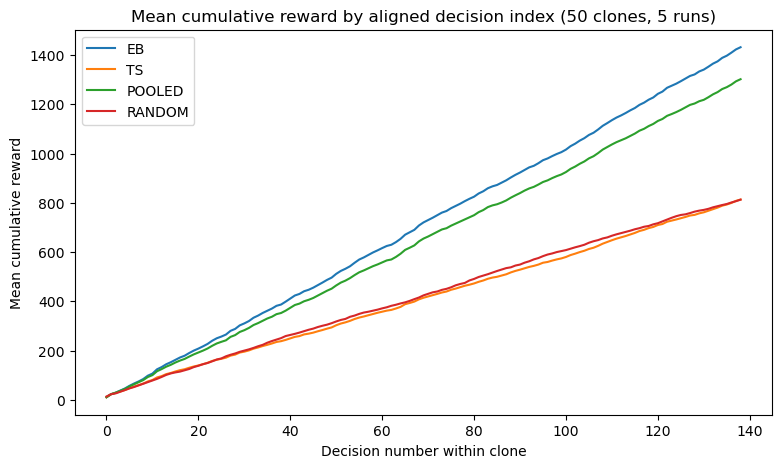

✅ Simulation results saved for all users and algorithms.


In [15]:
# ============================
# LOAD SAVED MODELS + STATIC FEATURES (NEW)
# ============================

import os
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, time
from collections import defaultdict
from sksurv.util import Surv
import pickle
import matplotlib.pyplot as plt

import warnings
from sklearn.exceptions import InconsistentVersionWarning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

# ---- paths ----
SURV_BUNDLE_PATH = "saved_survival_models/best_models_bundle.joblib"
BQ_DIR = "saved_brushing_quality_models"

# ---- load survival bundle (models + preproc + static_feature_lookup + true_brushing) ----
surv_bundle = joblib.load(SURV_BUNDLE_PATH)

best_model_per_user = surv_bundle["best_model_per_user"]
preproc_per_user = surv_bundle["preproc_per_user"]
static_feature_lookup = surv_bundle["static_feature_lookup"]
true_brushing = surv_bundle.get("true_brushing", None)  # should exist if you saved it

print("✅ Loaded survival models for:", len(best_model_per_user), "users")
print("✅ Loaded static_feature_lookup for:", len(static_feature_lookup), "users")
if true_brushing is not None:
    print("✅ Loaded true_brushing for:", len(true_brushing), "users")
else:
    print("⚠️ true_brushing not found in bundle. Some evaluation code may fail.")

def load_bq_payload(user_id, bq_dir=BQ_DIR):
    path = os.path.join(bq_dir, f"{user_id}_bq.joblib")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing brushing-quality model for {user_id}: {path}")
    return joblib.load(path)


# ============================
# Feedback features (unchanged)
# ============================

from sklearn.feature_selection import SelectKBest, f_regression

def safe_std_mean_ratio(hours):
    if len(hours) == 0 or np.mean(hours) == 0:
        return 0
    return round((np.std(hours) / np.mean(hours)), 2)

def compute_feedback_features(simulated_brushing_times, decision_time, start_date, static_features):
    morning_array, evening_array = [], []
    morning_hours, evening_hours = [], []
    morning_missed_count, evening_missed_count = 0, 0
    time_delta = static_features[-4]

    for i in range(1, 8):
        prior_day_time = decision_time + timedelta(days=-i)
        if prior_day_time.date() < start_date:
            continue

        morning_start = prior_day_time.replace(hour=4, minute=0, second=0, microsecond=0)
        morning_end = morning_start + timedelta(hours=12)
        evening_start = prior_day_time.replace(hour=16, minute=0, second=0, microsecond=0)
        evening_end = evening_start + timedelta(hours=12)

        # Morning brushing
        morning_bt = [bt for bt in simulated_brushing_times if morning_start <= bt < morning_end]
        if morning_bt:
            bt = morning_bt[0]
            delta = (bt - morning_start).total_seconds() / 3600
            morning_array.append(bt)
            morning_hours.append(round(delta, 2))
        else:
            morning_missed_count += 1

        # Evening brushing
        evening_bt = [bt for bt in simulated_brushing_times if evening_start <= bt < evening_end]
        if evening_bt:
            bt = evening_bt[0]
            delta = (bt - evening_start).total_seconds() / 3600
            evening_array.append(bt)
            evening_hours.append(round(delta, 2))
        else:
            evening_missed_count += 1

    if len(morning_array) == 0:
        morning_hours = [time_delta]
        morning_missed_count = 6
    if len(evening_array) == 0:
        evening_hours = [time_delta]
        evening_missed_count = 6

    morning_hours = np.array(morning_hours)
    evening_hours = np.array(evening_hours)

    morning_features = [
        np.min(morning_hours) if len(morning_hours) > 0 else 0,
        np.max(morning_hours) if len(morning_hours) > 0 else 0,
        np.median(morning_hours) if len(morning_hours) > 0 else 0,
        compute_exponential_avg(morning_hours),
        safe_std_mean_ratio(morning_hours),
        morning_missed_count,
    ]

    evening_features = [
        np.min(evening_hours) if len(evening_hours) > 0 else 0,
        np.max(evening_hours) if len(evening_hours) > 0 else 0,
        np.median(evening_hours) if len(evening_hours) > 0 else 0,
        compute_exponential_avg(evening_hours),
        safe_std_mean_ratio(evening_hours),
        evening_missed_count,
    ]

    if decision_time.hour == 4:
        brushing_stat_features = morning_features + evening_features
    else:
        brushing_stat_features = evening_features + morning_features

    past_windowed = [btime for btime in simulated_brushing_times if btime < decision_time]

    morning_brushes, evening_brushes = [], []
    for dt_key in past_windowed:
        if 4 <= dt_key.hour < 16:
            morning_brushes.append(dt_key)
        else:
            evening_brushes.append(dt_key)

    use_list = evening_brushes if decision_time.hour == 16 else morning_brushes

    if len(use_list) > 0:
        alpha = use_list[-1]
        last_brushing_days = (decision_time - alpha).days
        if last_brushing_days > 7:
            last_brushing_days = 7

        minutes_in_day = alpha.hour * 60 + alpha.minute
        if decision_time.hour == 16 and minutes_in_day <= 240:
            minutes_in_day += 1440

        reference_minutes_in_day = decision_time.hour * 60 + decision_time.minute
        most_recent_brushinghours = round((minutes_in_day - reference_minutes_in_day) / 60, 2)
    else:
        last_brushing_days = 1
        most_recent_brushinghours = time_delta

    most_recent_array = [last_brushing_days, most_recent_brushinghours]
    return brushing_stat_features + most_recent_array


# ============================
# Sampling from survival func
# ============================

def sample_from_survival(sf, t_max=12.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng

    t_grid = np.asarray(sf.x, dtype=float)
    S_grid = np.asarray(sf.y, dtype=float)

    mask = t_grid <= t_max
    t_grid = t_grid[mask]
    S_grid = S_grid[mask]

    if t_grid.size == 0:
        return False, float(t_max)

    if t_grid[0] > 0.0:
        t_grid = np.insert(t_grid, 0, 0.0)
        S_grid = np.insert(S_grid, 0, 1.0)

    if t_grid[-1] < t_max:
        t_grid = np.append(t_grid, t_max)
        S_grid = np.append(S_grid, S_grid[-1])

    u = rng.uniform()

    idx = np.argmax(S_grid <= u)
    if S_grid[idx] > u:
        return False, float(t_max)

    i0 = max(idx - 1, 0)
    t0, S0 = t_grid[i0], S_grid[i0]
    t1, S1 = t_grid[idx], S_grid[idx]

    if S0 == S1:
        t_star = t1
    else:
        w = (S0 - u) / (S0 - S1)
        w = float(np.clip(w, 0.0, 1.0))
        t_star = t0 + w * (t1 - t0)

    t_star = float(min(max(t_star, 0.0), t_max))
    return True, t_star


# ============================
# Apply saved survival preprocessing
# ============================

def apply_user_preproc(X_row, preproc):
    Xp = preproc["scaler"].transform(X_row)
    dropped_const = preproc.get("dropped_const", [])
    if dropped_const is not None and len(dropped_const) > 0:
        Xp = np.delete(Xp, dropped_const, axis=1)
    Xp = Xp[:, preproc["kept_idx"]]
    return Xp


def get_or_none(seq, idx, default=None):
    return seq[idx] if -len(seq) <= idx < len(seq) else default

def get_action_features(simulated_actions, action):
    past_actions = []
    for i in range(1, 8):
        if get_or_none(simulated_actions, -2 * i) is not None:
            past_actions.append(simulated_actions[-2 * i])

    past_actions = np.array(past_actions)
    past_actions_12_hours_back = 0
    if get_or_none(simulated_actions, -1) is not None:
        past_actions_12_hours_back = simulated_actions[-1]
    action_features = [compute_exponential_avg(past_actions), past_actions_12_hours_back, action]
    return action_features


# ============================
# Simulation
# ============================

def thompson_action_single(m, v, n_arms=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    m = np.asarray(m, dtype=float)
    v = np.maximum(np.asarray(v, dtype=float), 1e-6)

    sampled_values = rng.normal(loc=m, scale=np.sqrt(v))
    return int(np.argmax(sampled_values))


n_runs = 5
algorithms = ["eb", "ts", "pooled", "random"]

# preload brushing-quality payloads once
bq_payload_cache = {
    user_id: load_bq_payload(user_id)
    for user_id in best_model_per_user.keys()
}

# store cumulative reward traces across runs for each algorithm
cumulative_reward_runs = {alg: [] for alg in algorithms}

# keep simulation outputs separate by algorithm
simulation_columns_by_alg = {
    alg: defaultdict(lambda: {
        "decision_time": None,
        "true_result": None,
        "runs": []
    })
    for alg in algorithms
}

with open("user_app_opening.pkl", "rb") as f:
    user_app_opening_prob = pickle.load(f)

# ==========================================
# CREATE HOMOGENEOUS CLONED POPULATION
# ==========================================
source_user = list(best_model_per_user.keys())[2]   # or replace with a specific user id
n_clones = 50

print("SOURCE USER:", source_user)
print("Creating homogeneous population with", n_clones, "clones")

clone_ids = [f"clone_{i+1}" for i in range(n_clones)]

best_model_per_user_new = {}
preproc_per_user_new = {}
static_feature_lookup_new = {}
true_brushing_new = {} if true_brushing is not None else None
user_metadata_new = {}
user_app_opening_prob_new = {}
bq_payload_cache_new = {}

for clone_id in clone_ids:
    best_model_per_user_new[clone_id] = copy.deepcopy(best_model_per_user[source_user])
    preproc_per_user_new[clone_id] = copy.deepcopy(preproc_per_user[source_user])
    static_feature_lookup_new[clone_id] = copy.deepcopy(static_feature_lookup[source_user])

    if true_brushing is not None:
        true_brushing_new[clone_id] = copy.deepcopy(true_brushing[source_user])

    user_metadata_new[clone_id] = copy.deepcopy(user_metadata[source_user])
    user_app_opening_prob_new[clone_id] = copy.deepcopy(user_app_opening_prob[source_user])
    bq_payload_cache_new[clone_id] = copy.deepcopy(bq_payload_cache[source_user])

best_model_per_user = best_model_per_user_new
preproc_per_user = preproc_per_user_new
static_feature_lookup = static_feature_lookup_new
if true_brushing is not None:
    true_brushing = true_brushing_new
user_metadata = user_metadata_new
user_app_opening_prob = user_app_opening_prob_new
bq_payload_cache = bq_payload_cache_new

print("Homogeneous cloned population created.")
print("Total users now:", len(best_model_per_user))
print("Clone IDs example:", list(best_model_per_user.keys())[:5])




avg_average_brush_sim = {alg: [] for alg in algorithms}
std_average_brush_sim = {alg: [] for alg in algorithms}
avg_prop_right_censored = {alg: [] for alg in algorithms}
std_prop_right_censored = {alg: [] for alg in algorithms}
avg_p90_brush_sim = {alg: [] for alg in algorithms}
std_p90_brush_sim = {alg: [] for alg in algorithms}
avg_std_brush_sim = {alg: [] for alg in algorithms}
std_std_brush_sim = {alg: [] for alg in algorithms}
avg_median_brush_sim = {alg: [] for alg in algorithms}
std_median_brush_sim = {alg: [] for alg in algorithms}

mu_0 = [-0.12, 0, -0.60, 0, 1.31, -0.50, 0.40, 0.38, 0.33, 5.68]
sigma_0 = [(1.30)**2, (0.16)**2, (1.06)**2, (0.57)**2, (1.51)**2, (1.21)**2, (0.50)**2, (0.37)**2, (1.93)**2, (1.91)**2]
alpha_0, beta_0 = 5.01, 21.73

# C controls how strictly to align intervention time with brushing time.
C = 5
alpha = 1
variant = "Baseline"

for alg_name in algorithms:
    print(f"\n===== Running algorithm: {alg_name.upper()} =====")

    for run in range(n_runs):
        print(f"Simulation run {run}")
        rng = np.random.default_rng(run)
        n_arms = 2

        target_user = list(best_model_per_user.keys())[2]   # or a specific user id
        print("TARGET USER IS ", target_user)

        all_bandit_histories = {
            uid: {"rewards": [], "actions": []}
            for uid in best_model_per_user.keys()
        }
        # all_bandit_histories = {
        #     target_user: {"rewards": [], "actions": []}
        # }

        # reward_trace = []
        reward_traces_by_user = []


        r_a, r_b = [], []
        s_a, s_b = [], []
        t_a, t_b = [], []
        u_a, u_b = [], []
        v_a, v_b = [], []

        coverage_model = []
        coverage_user = []

        cumulative_model_outcome = []
        cumulative_user_outcome = []

    

        for user_id in best_model_per_user.keys():
            user_reward_trace = []
            
        # for user_id in [target_user]:
            start_date = datetime.strptime(
                user_metadata[user_id]["user_start_day"], "%Y-%m-%d"
            ).date()

            static_df = static_feature_lookup[user_id]
            decision_times = sorted(static_df.keys())

            pipeline = best_model_per_user[user_id]
            preproc = preproc_per_user[user_id]

            if true_brushing is None:
                raise ValueError("true_brushing not loaded from bundle; cannot compute evaluation.")
            Y_true = true_brushing[user_id]

            # ---- load brushing quality model from cache ----
            bq_payload = bq_payload_cache[user_id]
            user_brushingquality_model = bq_payload["model"]
            user_brushingquality_features = bq_payload.get("features", None)

            if "preproc" in bq_payload:
                user_brushingquality_scaler = bq_payload["preproc"]["scaler"]
                user_brushingquality_dropped_const = bq_payload["preproc"].get("dropped_const", [])
            else:
                user_brushingquality_scaler = bq_payload["scaler"]
                user_brushingquality_dropped_const = []

            if simulation_columns_by_alg[alg_name][user_id]["decision_time"] is None:
                simulation_columns_by_alg[alg_name][user_id]["decision_time"] = decision_times
                simulation_columns_by_alg[alg_name][user_id]["true_result"] = [
                    (event, round(tt, 2)) for event, tt in zip(Y_true["event"], Y_true["time"])
                ]

            Y_simulated = []
            simulated_brushing_times = []
            simulated_actions = []
            simulated_brush_time = []
            simulated_brush_quality = []
            simulated_app_opening = []
            participant_model_outcome = []
            participant_user_outcome = []

            rewards = all_bandit_histories[user_id]["rewards"]
            actions = all_bandit_histories[user_id]["actions"]

            intervention_time_model = BayesLinRegUnknownVariance(
                np.array(mu_0), np.array(sigma_0), alpha_0, beta_0
            )

            col_means = np.array([0.45, 2.94, 3.36, 7.24, 5.24, 0.30, 1.61, 5.87, 4.41, 0])
            col_stds  = np.array([0.50, 1.98, 2.40, 2.85, 2.30, 0.24, 1.99, 2.73, 1.59, 1])

            model_success, model_fail = 0, 0
            user_success, user_fail = 0, 0

            for decision_time in decision_times:
                static_features_temp = static_df[decision_time]

                feedback_features_temp = compute_feedback_features(
                    simulated_brushing_times, decision_time, start_date, static_features_temp
                )

                # --- action selection ---
                if len(actions) == 0:
                    action = int(rng.integers(n_arms))
                else:
                    m, v = simple_normal_learner(rewards, actions, n_arms)

                    if alg_name == "eb":
                        mu_hat_global, tau2_hat_global = estimate_global_eb_hyperparams(
                            all_bandit_histories, n_arms
                        )
                        action, m_eb, v_eb = empirical_bayes_action_single(
                            m=m,
                            v=v,
                            mu_hat=mu_hat_global,
                            tau2_hat=tau2_hat_global,
                            n_arms=n_arms,
                            rng=rng
                        )
                    elif alg_name == "ts":
                        action = thompson_action_single(
                            m=m,
                            v=v,
                            n_arms=n_arms,
                            rng=rng
                        )
                    elif alg_name == "pooled":
                        m_pool, v_pool = pooled_normal_learner(all_bandit_histories, n_arms)
                        action = thompson_action_single(m_pool, v_pool, n_arms=n_arms, rng=rng)
                    elif alg_name == "random":
                        action = int(rng.integers(n_arms))   # 0 or 1 with probability 1/2 each
                    else:
                        raise ValueError(f"Unknown algorithm: {alg_name}")

                action_features = get_action_features(simulated_actions, action)

                # IMPORTANT: must match training feature construction
                X_now = static_features_temp[:3] + feedback_features_temp + [static_features_temp[-4]] + action_features

                if intervention_time_model.has_data():
                    mu_n, Sigma_n, alpha_n, beta_n = intervention_time_model.posterior()
                else:
                    mu_n, Sigma_n, alpha_n, beta_n = mu_0, np.diag(sigma_0), alpha_0, beta_0

                X_intervention_time = [
                    X_now[0], X_now[2],
                    feedback_features_temp[0], feedback_features_temp[1],
                    feedback_features_temp[3], feedback_features_temp[4], feedback_features_temp[5],
                    feedback_features_temp[-1],
                    X_now[-4],
                    1
                ]
                X_intervention_time = np.array(X_intervention_time).reshape(1, -1)
                X_intervention_time = (X_intervention_time - col_means) / col_stds

                pred_mean, pred_var = intervention_time_model.predict_given(
                    mu_n, Sigma_n, alpha_n, beta_n, X_intervention_time
                )
                intervention_timemodel = pred_mean - alpha * np.sqrt(pred_var)
                intervention_timemodel = max(1, min(11, intervention_timemodel))

                user_providedtime = X_now[-4] - 1

                X_now = np.array(X_now, dtype=float).reshape(1, -1)

                # Apply saved survival preprocessing
                X_now_proc = apply_user_preproc(X_now, preproc)

                # Predict survival function
                surv_func = pipeline.predict_survival_function(X_now_proc)[0]

                if variant == "Baseline":
                    sampled_brush_status, sampled_brush_time = sample_from_survival(
                        surv_func, t_max=12.0, rng=rng
                    )
                else:
                    sampled_brush_status, sampled_brush_time = sample_from_survival(
                        surv_func, t_max=12.0, rng=rng
                    )

                if sampled_brush_status:
                    sampled_brush_quality = get_simulated_brush_quality(
                        user_brushingquality_model,
                        user_brushingquality_scaler,
                        user_brushingquality_features,
                        decision_time, start_date,
                        simulated_brush_time, simulated_actions, simulated_brush_quality,
                        action, user_providedtime + 1
                    )

                    if 0 < sampled_brush_time - intervention_timemodel <= C:
                        reward = float(sampled_brush_quality) if sampled_brush_quality is not None else 0.0
                        model_success += 1
                        participant_model_outcome.append(reward)
                    else:
                        reward = 0.0
                        participant_model_outcome.append(0.0)
                        model_fail += 1

                    intervention_time_model.update(X_intervention_time, sampled_brush_time)
                else:
                    sampled_brush_quality = None
                    reward = 0.0
                    participant_model_outcome.append(0.0)

                # update local/global bandit history
                actions.append(action)
                rewards.append(reward)
                # reward_trace.append(reward)
                user_reward_trace.append(reward)

                Y_simulated.append([sampled_brush_status, sampled_brush_time])
                simulated_actions.append(action)
                simulated_brush_time.append([sampled_brush_status, round(sampled_brush_time, 2)])
                simulated_brush_quality.append(sampled_brush_quality)

                if rng.random() > user_app_opening_prob[user_id]:
                    simulated_app_opening.append(1)
                else:
                    simulated_app_opening.append(0)

                if sampled_brush_status:
                    simulated_brushing_times.append(decision_time + timedelta(hours=sampled_brush_time))

            coverage_model.append(
                model_success / (model_success + model_fail)
                if (model_success + model_fail) > 0 else 0.0
            )
            coverage_user.append(
                user_success / (user_success + user_fail)
                if (user_success + user_fail) > 0 else 0.0
            )

            cumulative_model_outcome.append(
                float(np.mean(participant_model_outcome)) if len(participant_model_outcome) else 0.0
            )

            row_data = [(e, round(d, 2)) for e, d in Y_simulated]
            simulation_columns_by_alg[alg_name][user_id]["runs"].append(row_data)

            # ---- evaluation ----
            event = [y[0] for y in Y_simulated]
            duration = [y[1] for y in Y_simulated]
            Y_simulated_structured = Surv.from_arrays(event, duration)

            a = evaluate_simulation(Y_true, Y_simulated_structured)
            r_a.append(a["prop_censored_true"]); r_b.append(a["prop_censored_sim"])
            s_a.append(a["mean_time_true"]);     s_b.append(a["mean_time_sim"])
            t_a.append(a["p90_time_true"]);      t_b.append(a["p90_time_sim"])
            u_a.append(a["std_time_true"]);      u_b.append(a["std_time_sim"])
            v_a.append(a["median_time_true"]);   v_b.append(a["median_time_sim"])

            reward_traces_by_user.append(user_reward_trace)

        # cumulative_reward = np.cumsum(reward_trace)
        # cumulative_reward_runs[alg_name].append(cumulative_reward)
        reward_matrix = np.vstack(reward_traces_by_user)   # (n_users, n_decisions)
        mean_reward_per_step = reward_matrix.mean(axis=0)  # (n_decisions,)
        cumulative_reward = np.cumsum(mean_reward_per_step)
        cumulative_reward_runs[alg_name].append(cumulative_reward)

        avg_average_brush_sim[alg_name].append(np.mean(s_b))
        std_average_brush_sim[alg_name].append(np.std(s_b))
        avg_prop_right_censored[alg_name].append(np.mean(r_b))
        std_prop_right_censored[alg_name].append(np.std(r_b))
        avg_p90_brush_sim[alg_name].append(np.mean(t_b))
        std_p90_brush_sim[alg_name].append(np.std(t_b))
        avg_std_brush_sim[alg_name].append(np.mean(u_b))
        std_std_brush_sim[alg_name].append(np.std(u_b))
        avg_median_brush_sim[alg_name].append(np.mean(v_b))
        std_median_brush_sim[alg_name].append(np.std(v_b))

# ============================
# Plot mean cumulative reward over time
# ============================

plt.figure(figsize=(9, 5))

for alg_name in algorithms:
    curves = cumulative_reward_runs[alg_name]
    curve_matrix = np.vstack(curves)
    mean_curve = curve_matrix.mean(axis=0)
    plt.plot(mean_curve, label=alg_name.upper())

# plt.xlabel("Decision step")
plt.xlabel("Decision number within clone")
plt.ylabel("Mean cumulative reward")
# plt.title(f"Mean cumulative reward over time ({n_runs} run(s))")
# plt.title(f"Mean cumulative reward over time for user {target_user} ({n_runs} run(s))")
# plt.title(f"Mean cumulative reward (homogeneous cloned population, {n_runs} runs)")
plt.title(f"Mean cumulative reward by aligned decision index ({len(best_model_per_user)} clones, {n_runs} runs)")
plt.legend()
plt.show()

# ============================
# Save simulation runs
# ============================

os.makedirs("simulated_brushingtime_runs", exist_ok=True)

for alg_name in algorithms:
    alg_dir = os.path.join("simulated_brushingtime_runs", alg_name)
    os.makedirs(alg_dir, exist_ok=True)

    for user_id in simulation_columns_by_alg[alg_name]:
        base = simulation_columns_by_alg[alg_name][user_id]
        base_cols = {
            "decision_time": base["decision_time"],
            "true_result": base["true_result"]
        }
        sim_cols = {f"sim_{i+1}": base["runs"][i] for i in range(len(base["runs"]))}

        df = pd.concat([pd.DataFrame(base_cols), pd.DataFrame(sim_cols)], axis=1)
        file_name = f"{user_id}_{alg_name}_simulations.csv"
        df.to_csv(os.path.join(alg_dir, file_name), index=False)

print("✅ Simulation results saved for all users and algorithms.")